In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

In [2]:
import neuroboros as nb
import numpy as np
from scipy.stats import ttest_rel
import scipy.stats as stats

/dartfs-hpc/rc/home/q/f007d9q/neuroboros/src/neuroboros/io.py:56: UserWarning: DataLad dataset core exists at /dartfs-hpc/rc/home/q/f007d9q/.neuroboros-data/core, but does not have source https://gin.g-node.org/neuroboros/core as a sibling.
  warnings.warn(


In [3]:
results = nb.load('summary/isc_camcan.pkl')

In [4]:
list(results)

[('young', 'young'),
 ('mid', 'young'),
 ('old', 'young'),
 ('young', 'mid'),
 ('mid', 'mid'),
 ('old', 'mid'),
 ('young', 'old'),
 ('mid', 'old'),
 ('old', 'old')]

In [6]:
results 

{('young',
  'young'): array([[[0.27325257, 0.70391895, 0.46306433, ..., 0.48279052,
          0.53489075, 0.1720937 ],
         [0.72923633, 0.75074463, 0.75602116, ..., 0.55917508,
          0.86508072, 0.15810861],
         [0.41793237, 0.60947061, 0.40781561, ..., 0.55639709,
          0.7180295 , 0.38449496],
         ...,
         [0.80466066, 0.77961643, 0.61995166, ..., 0.58069528,
          0.4309996 , 0.40850131],
         [0.80700523, 0.86643364, 0.8012345 , ..., 0.6168249 ,
          0.81304101, 0.7230938 ],
         [0.78942941, 0.82578836, 0.55556767, ..., 0.43537448,
          0.5868134 , 0.79797363]],
 
        [[0.87493225, 0.8129569 , 0.82669555, ..., 0.7242507 ,
          0.78377845, 0.75987689],
         [0.81741012, 0.81085942, 0.7438403 , ..., 0.68435537,
          0.73566533, 0.83297296],
         [0.70150915, 0.72694045, 0.78053283, ..., 0.62706355,
          0.87880181, 0.65673385],
         ...,
         [0.78162126, 0.85605924, 0.8313619 , ..., 0.45861238,
  

In [34]:
for test_grp in ['mid', 'young']:
    for tpl_grp in ['mid', 'young']:
        print(results[test_grp, tpl_grp].shape)

(10, 71, 19341)
(10, 71, 19341)
(10, 71, 19341)
(10, 71, 19341)


In [35]:
test_lists = nb.load('summary/camcan_test_lists.pkl')

In [66]:
zz = {}
for test_grp in ['mid', 'young']:
    for tpl_grp in ['mid', 'young']:
        sid_results = {}
        for trial in range(10):
            sids = test_lists[test_grp, trial]
            vals = results[test_grp, tpl_grp][trial]
            for sid, val in zip(sids, vals):
                if sid not in sid_results:
                    sid_results[sid] = []
                sid_results[sid].append(val)
        res = [np.mean(np.arctanh(sid_results[sid]), axis=0) for sid in sid_results]
        print(np.unique([len(sid_results[sid]) for sid in sid_results], return_counts=True))
        res = np.stack(res, axis=0)
        print(res.shape)
        zz[test_grp, tpl_grp] = res.mean(axis=1)

(array([1, 2, 3, 4, 5, 6, 8]), array([19, 37, 62, 48, 27, 16,  1]))
(210, 19341)
(array([1, 2, 3, 4, 5, 6, 8]), array([19, 37, 62, 48, 27, 16,  1]))
(210, 19341)
(array([1, 2, 3, 4, 5, 6, 8]), array([19, 37, 62, 48, 27, 16,  1]))
(210, 19341)
(array([1, 2, 3, 4, 5, 6, 8]), array([19, 37, 62, 48, 27, 16,  1]))
(210, 19341)


In [67]:
rocket = sns.color_palette("rocket", 5)
mako = sns.color_palette("mako", 5)

colors = [mpl.colors.to_rgb(mpl.colors.cnames[_])
          for _ in ['darkgreen', 'lightgreen', 'red', 'pink']]

config = [
    [0, zz['mid', 'mid'], rocket[2]],
    [1, zz['mid', 'young'], rocket[4]],
    [2.5, zz['young', 'young'], mako[2]],
    [3.5, zz['young', 'mid'], mako[4]],
]

In [38]:
def bootstrap_mean(d, rng=0, n_reps=100000):
    n = d.shape[0]
    rng = np.random.default_rng(rng)
    stats = np.zeros((n_reps,))
    for i in range(n_reps):
        sample = rng.choice(d, (n,), replace=True)
        stats[i] = sample.mean()
    return stats

In [68]:
d1 = zz['mid', 'mid'] - zz['mid', 'young']
d2 = zz['young', 'young'] - zz['young', 'mid']

m1 = d1.mean()
se1 = d1.std(ddof=1) / np.sqrt(len(d1))
# b1 = bootstrap_mean(d1)
# yerr1 = np.abs(np.percentile(b1, [2.5, 97.5]) - m1)
m2 = d2.mean()
se2 = d2.std(ddof=1) / np.sqrt(len(d2))
# b2 = bootstrap_mean(d2)
# yerr2 = np.abs(np.percentile(b2, [2.5, 97.5]) - m2)


In [69]:
print(m1)
print(se1)
print(m2)
print(se2)

-0.0009274029675357255
0.0005172485536920088
0.006440239514681169
0.0003176229450456903


In [70]:
colors = [np.array(mpl.colors.to_rgb(mpl.colors.cnames[_]))
          for _ in ['darkgreen', 'lightgreen', 'red', 'pink']]
c1 = (colors[0] + colors[1]) * 0.5
c2 = (colors[2] + colors[3]) * 0.5

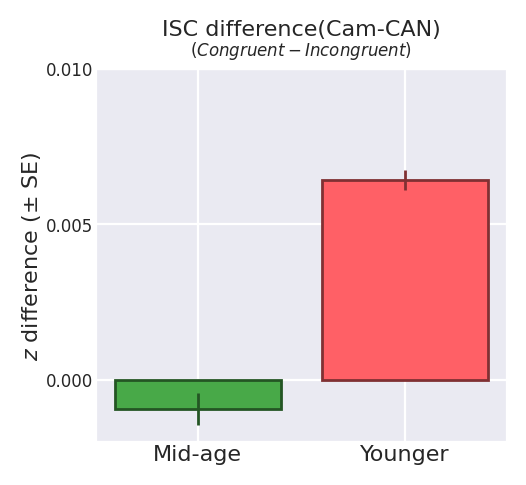

In [72]:
with sns.axes_style('darkgrid'):
    fig, ax = plt.subplots(1, 1, figsize=[_/3 for _ in [8, 8]], dpi=200)
    
    kwargs = dict(fmt='', lw=1)
    ax.bar(0, m1, color=c1, ec=c1*0.5)
    ax.bar(1, m2, color=c2, ec=c2*0.5)
    ax.errorbar(0, m1, yerr=se1, c=c1*0.5, **kwargs)
    ax.errorbar(1, m2, yerr=se2, c=c2*0.5, **kwargs)
    
    ax.set_ylim(-0.002, 0.01)  
    ax.set_yticks([0, 0.005, 0.01]) 

    ax.tick_params(size=0, pad=1, labelsize=6)
    ax.set_xticks([0, 1], labels=['Mid-age', 'Younger'], size=8)
    ax.set_ylabel('$z$ difference (± SE)', size=8, labelpad=1)
    
    # --- Main Title ---
    ax.set_title('ISC difference(Cam-CAN)', size=8, pad=12)
    
    # --- Smaller Subtitle ---
    # We place this at x=0.5 (center) and y=1.02 (just above the axes)
    ax.text(0.5, 1.02, '$(Congruent - Incongruent)$', 
            fontsize=6, ha='center', va='bottom', transform=ax.transAxes)

    # Lower 'top' to 0.82 to ensure both lines are visible
    fig.subplots_adjust(left=0.18, top=0.82, bottom=0.12, right=0.95)
    
    plt.savefig('figures/isc_diff_camcan_mid&young.png', dpi=300, bbox_inches='tight')
    plt.show()

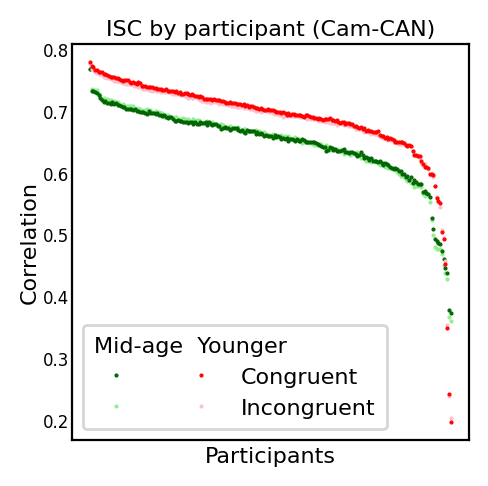

In [73]:
fig, ax = plt.subplots(1, 1, figsize=[_/3 for _ in [7, 7]], dpi=200)
handles = []
for ii, (a, b) in enumerate([[zz['mid', 'mid'], zz['mid', 'young']], [zz['young', 'young'], zz['young', 'mid']]]):
    # with sns.axes_style('darkgrid'):
        # idx = np.argsort(a)[::-1]
        idx = np.argsort((a + b))[::-1]
        a, b = np.tanh(a[idx]), np.tanh(b[idx])
        x = np.arange(len(a))
        kwargs = dict(markersize=1)
        handles += ax.plot(x, b, '.', color=colors[ii*2+1], **kwargs)
        handles += ax.plot(x, a, '.', color=colors[ii*2], **kwargs)
handles = [handles[_] for _ in [1, 0, 3, 2]]
ax.tick_params(size=0, pad=1, labelsize=6)
ax.set_ylabel('Correlation', size=8, labelpad=1)
ax.set_xticks([])
ax.set_xlabel('Participants', size=8, labelpad=2)
ax.set_title('ISC by participant (Cam-CAN)', size=8, pad=3)
ax.legend(handles=handles, labels=['', '', 'Congruent', 'Incongruent'], ncols=2, columnspacing=1, fontsize=8,
         title='Mid-age  Younger', title_fontsize=8, alignment='left', borderpad=0.5, fancybox=True)
fig.subplots_adjust(left=0.13, top=0.92, bottom=0.07, right=0.98)
plt.savefig('figures/isc_dist_camcan_mid&young.png', dpi=300)
plt.show()

In [47]:
for test_grp in ['mid', 'old']:
    for tpl_grp in ['mid', 'old']:
        print(results[test_grp, tpl_grp].shape)

(10, 71, 19341)
(10, 71, 19341)
(10, 72, 19341)
(10, 72, 19341)


In [48]:
test_lists = nb.load('summary/camcan_test_lists.pkl')

In [57]:
zz = {}
for test_grp in ['mid', 'old']:
    for tpl_grp in ['mid', 'old']:
        sid_results = {}
        for trial in range(10):
            sids = test_lists[test_grp, trial]
            vals = results[test_grp, tpl_grp][trial]
            for sid, val in zip(sids, vals):
                if sid not in sid_results:
                    sid_results[sid] = []
                sid_results[sid].append(val)
        res = [np.mean(np.arctanh(sid_results[sid]), axis=0) for sid in sid_results]
        print(np.unique([len(sid_results[sid]) for sid in sid_results], return_counts=True))
        res = np.stack(res, axis=0)
        print(res.shape)
        zz[test_grp, tpl_grp] = res.mean(axis=1)

(array([1, 2, 3, 4, 5, 6, 8]), array([19, 37, 62, 48, 27, 16,  1]))
(210, 19341)
(array([1, 2, 3, 4, 5, 6, 8]), array([19, 37, 62, 48, 27, 16,  1]))
(210, 19341)
(array([1, 2, 3, 4, 5, 6, 7, 8]), array([18, 43, 55, 51, 33, 10,  2,  1]))
(213, 19341)
(array([1, 2, 3, 4, 5, 6, 7, 8]), array([18, 43, 55, 51, 33, 10,  2,  1]))
(213, 19341)


In [58]:
rocket = sns.color_palette("rocket", 5)
mako = sns.color_palette("mako", 5)

colors = [mpl.colors.to_rgb(mpl.colors.cnames[_])
          for _ in ['darkgreen', 'lightgreen', 'red', 'pink']]

config = [
    [0, zz['old', 'old'], rocket[2]],
    [1, zz['old', 'mid'], rocket[4]],
    [2.5, zz['mid', 'mid'], mako[2]],
    [3.5, zz['mid', 'old'], mako[4]],
]

In [59]:
d1 = (zz['old', 'old'] - zz['old', 'mid'])
d2 = (zz['mid', 'mid'] - zz['mid', 'old'])

m1 = d1.mean()
se1 = d1.std(ddof=1) / np.sqrt(len(d1))
# b1 = bootstrap_mean(d1)
# yerr1 = np.abs(np.percentile(b1, [2.5, 97.5]) - m1)
m2 = d2.mean()
se2 = d2.std(ddof=1) / np.sqrt(len(d2))
# b2 = bootstrap_mean(d2)
# yerr2 = np.abs(np.percentile(b2, [2.5, 97.5]) - m2)


In [65]:
print(m1)
print(se1)
print(m2)
print(se2)

0.007911809014187149
0.0009069679805722558
0.008819714623509022
0.0006632854912575013


In [60]:
colors = [np.array(mpl.colors.to_rgb(mpl.colors.cnames[_]))
          for _ in ['darkgreen', 'lightgreen', 'red', 'pink']]
c1 = (colors[0] + colors[1]) * 0.5
c2 = (colors[2] + colors[3]) * 0.5

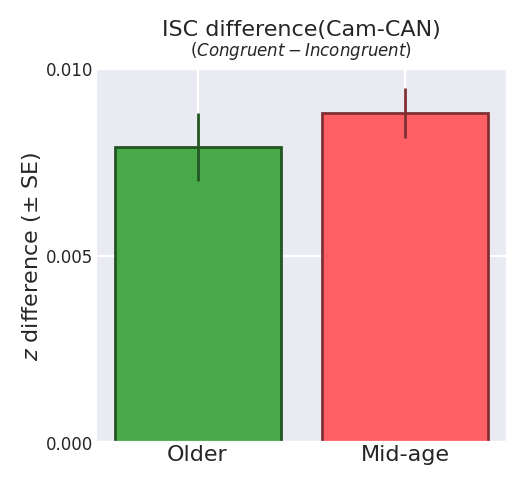

In [62]:
with sns.axes_style('darkgrid'):
    fig, ax = plt.subplots(1, 1, figsize=[_/3 for _ in [8, 8]], dpi=200)
    
    kwargs = dict(fmt='', lw=1)
    ax.bar(0, m1, color=c1, ec=c1*0.5)
    ax.bar(1, m2, color=c2, ec=c2*0.5)
    ax.errorbar(0, m1, yerr=se1, c=c1*0.5, **kwargs)
    ax.errorbar(1, m2, yerr=se2, c=c2*0.5, **kwargs)
    
    ax.set_ylim(0, 0.01)  
    ax.set_yticks([0, 0.005, 0.01]) 

    ax.tick_params(size=0, pad=1, labelsize=6)
    ax.set_xticks([0, 1], labels=['Older', 'Mid-age'], size=8)
    ax.set_ylabel('$z$ difference (± SE)', size=8, labelpad=1)
    
    # --- Main Title ---
    ax.set_title('ISC difference(Cam-CAN)', size=8, pad=12)
    
    # --- Smaller Subtitle ---
    # We place this at x=0.5 (center) and y=1.02 (just above the axes)
    ax.text(0.5, 1.02, '$(Congruent - Incongruent)$', 
            fontsize=6, ha='center', va='bottom', transform=ax.transAxes)

    # Lower 'top' to 0.82 to ensure both lines are visible
    fig.subplots_adjust(left=0.18, top=0.82, bottom=0.12, right=0.95)
    
    plt.savefig('figures/isc_diff_camcan_mid&old.png', dpi=300, bbox_inches='tight')
    plt.show()

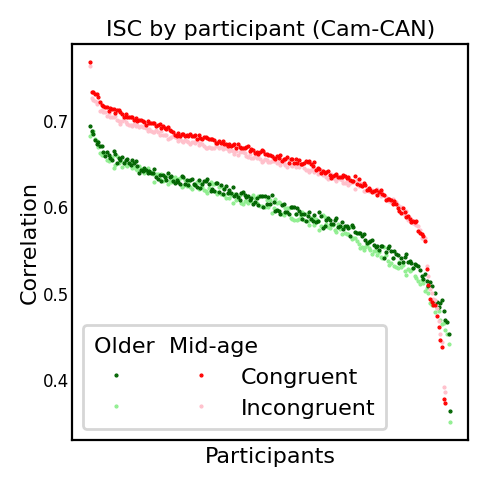

In [64]:
fig, ax = plt.subplots(1, 1, figsize=[_/3 for _ in [7, 7]], dpi=200)
handles = []
for ii, (a, b) in enumerate([[zz['old', 'old'], zz['old', 'mid']], [zz['mid', 'mid'], zz['mid', 'old']]]):
    # with sns.axes_style('darkgrid'):
        # idx = np.argsort(a)[::-1]
        idx = np.argsort((a + b))[::-1]
        a, b = np.tanh(a[idx]), np.tanh(b[idx])
        x = np.arange(len(a))
        kwargs = dict(markersize=1)
        handles += ax.plot(x, b, '.', color=colors[ii*2+1], **kwargs)
        handles += ax.plot(x, a, '.', color=colors[ii*2], **kwargs)
handles = [handles[_] for _ in [1, 0, 3, 2]]
ax.tick_params(size=0, pad=1, labelsize=6)
ax.set_ylabel('Correlation', size=8, labelpad=1)
ax.set_xticks([])
ax.set_xlabel('Participants', size=8, labelpad=2)
ax.set_title('ISC by participant (Cam-CAN)', size=8, pad=3)
ax.legend(handles=handles, labels=['', '', 'Congruent', 'Incongruent'], ncols=2, columnspacing=1, fontsize=8,
         title='Older  Mid-age', title_fontsize=8, alignment='left', borderpad=0.5, fancybox=True)
fig.subplots_adjust(left=0.13, top=0.92, bottom=0.07, right=0.98)
plt.savefig('figures/isc_dist_camcan_mid&old.png', dpi=300)
plt.show()

In [20]:
for test_grp in ['old', 'young']:
    for tpl_grp in ['old', 'young']:
        print(results[test_grp, tpl_grp].shape)

(10, 72, 19341)
(10, 72, 19341)
(10, 71, 19341)
(10, 71, 19341)


In [21]:
test_lists = nb.load('summary/camcan_test_lists.pkl')

In [22]:
zz = {}
for test_grp in ['old', 'young']:
    for tpl_grp in ['old', 'young']:
        sid_results = {}
        for trial in range(10):
            sids = test_lists[test_grp, trial]
            vals = results[test_grp, tpl_grp][trial]
            for sid, val in zip(sids, vals):
                if sid not in sid_results:
                    sid_results[sid] = []
                sid_results[sid].append(val)
        res = [np.mean(np.arctanh(sid_results[sid]), axis=0) for sid in sid_results]
        print(np.unique([len(sid_results[sid]) for sid in sid_results], return_counts=True))
        res = np.stack(res, axis=0)
        print(res.shape)
        zz[test_grp, tpl_grp] = res.mean(axis=1)

(array([1, 2, 3, 4, 5, 6, 7, 8]), array([18, 43, 55, 51, 33, 10,  2,  1]))
(213, 19341)
(array([1, 2, 3, 4, 5, 6, 7, 8]), array([18, 43, 55, 51, 33, 10,  2,  1]))
(213, 19341)
(array([1, 2, 3, 4, 5, 6, 8]), array([19, 37, 62, 48, 27, 16,  1]))
(210, 19341)
(array([1, 2, 3, 4, 5, 6, 8]), array([19, 37, 62, 48, 27, 16,  1]))
(210, 19341)


In [23]:
zz

{('old',
  'old'): array([0.79082587, 0.50622878, 0.74207744, 0.60534923, 0.73430659,
        0.67091096, 0.78319145, 0.60443537, 0.62249479, 0.64171717,
        0.74227186, 0.68465557, 0.66822832, 0.73746137, 0.65824776,
        0.6920091 , 0.71200084, 0.78589047, 0.78848285, 0.65692532,
        0.77630018, 0.68581595, 0.8099431 , 0.61612027, 0.79305113,
        0.73537756, 0.73338759, 0.6470568 , 0.62713502, 0.69829956,
        0.74156673, 0.7123055 , 0.66723894, 0.53638154, 0.74851877,
        0.72958748, 0.59556411, 0.67313044, 0.61498301, 0.66245267,
        0.76432461, 0.66582291, 0.50929977, 0.75213062, 0.5795536 ,
        0.5978745 , 0.67730056, 0.56576366, 0.74546654, 0.72179754,
        0.61771593, 0.74121173, 0.65301629, 0.61085566, 0.59642533,
        0.54909685, 0.77961343, 0.81036739, 0.75717413, 0.62945041,
        0.77025875, 0.71774728, 0.65595842, 0.75022392, 0.69536682,
        0.61597086, 0.64851592, 0.59120597, 0.55961328, 0.66947732,
        0.73434455, 0.75924216

In [24]:
rocket = sns.color_palette("rocket", 5)
mako = sns.color_palette("mako", 5)

colors = [mpl.colors.to_rgb(mpl.colors.cnames[_])
          for _ in ['darkgreen', 'lightgreen', 'red', 'pink']]

config = [
    [0, zz['old', 'old'], rocket[2]],
    [1, zz['old', 'young'], rocket[4]],
    [2.5, zz['young', 'young'], mako[2]],
    [3.5, zz['young', 'old'], mako[4]],
]

In [25]:
def bootstrap_mean(d, rng=0, n_reps=100000):
    n = d.shape[0]
    rng = np.random.default_rng(rng)
    stats = np.zeros((n_reps,))
    for i in range(n_reps):
        sample = rng.choice(d, (n,), replace=True)
        stats[i] = sample.mean()
    return stats

In [26]:
d1 = zz['old', 'old'] - zz['old', 'young']
d2 = zz['young', 'young'] - zz['young', 'old']

m1 = d1.mean()
se1 = d1.std(ddof=1) / np.sqrt(len(d1))
# b1 = bootstrap_mean(d1)
# yerr1 = np.abs(np.percentile(b1, [2.5, 97.5]) - m1)
m2 = d2.mean()
se2 = d2.std(ddof=1) / np.sqrt(len(d2))
# b2 = bootstrap_mean(d2)
# yerr2 = np.abs(np.percentile(b2, [2.5, 97.5]) - m2)


In [27]:
len(d1)

213

In [28]:
np.sum(d1 > 0)

158

In [29]:
len(d2)

210

In [30]:
np.sum(d2 > 0)

205

In [31]:
stats.ttest_1samp(d1, 0)

TtestResult(statistic=11.333590064196661, pvalue=1.3821119150163643e-23, df=212)

In [32]:
stats.ttest_1samp(d2, 0)

TtestResult(statistic=30.09154736366541, pvalue=6.627334444999082e-78, df=209)

(array([ 5., 11., 25., 21., 23., 29., 45., 35., 11.,  8.]),
 array([-0.04075354, -0.02950078, -0.01824802, -0.00699526,  0.0042575 ,
         0.01551026,  0.02676302,  0.03801578,  0.04926854,  0.0605213 ,
         0.07177406]),
 <BarContainer object of 10 artists>)

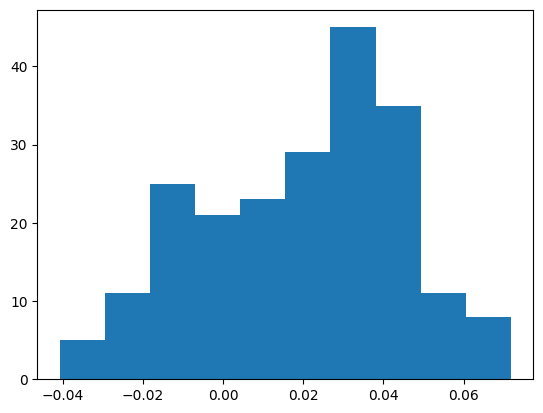

In [13]:
plt.hist(d1)

In [14]:
colors = [np.array(mpl.colors.to_rgb(mpl.colors.cnames[_]))
          for _ in ['darkgreen', 'lightgreen', 'red', 'pink']]
c1 = (colors[0] + colors[1]) * 0.5
c2 = (colors[2] + colors[3]) * 0.5

In [17]:
m1

0.019673579345782604

In [18]:
m2

0.022885612811688036

In [19]:
se1 

0.0017358647378585147

In [20]:
se2

0.000760532934219318

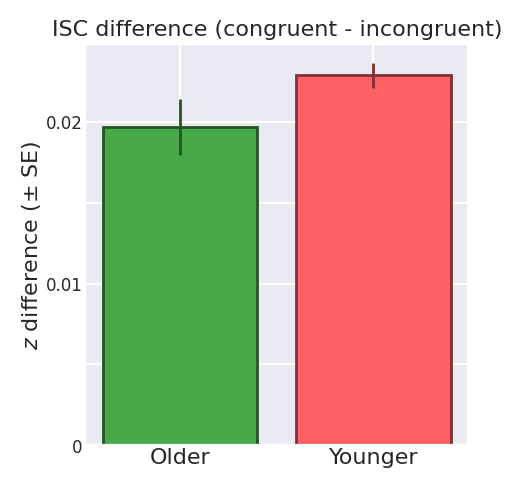

In [33]:
with sns.axes_style('darkgrid'):
    fig, ax = plt.subplots(1, 1, figsize=[_/3 for _ in [7, 7]], dpi=200)
    
    kwargs = dict(fmt='', lw=1)
    ax.bar(0, m1, color=c1, ec=c1*0.5)
    ax.bar(1, m2, color=c2, ec=c2*0.5)
    ax.errorbar(0, m1, yerr=se1, c=c1*0.5, **kwargs)
    ax.errorbar(1, m2, yerr=se2, c=c2*0.5, **kwargs)
    ax.tick_params(size=0, pad=1, labelsize=6)
    ax.set_xticks([0, 1], labels=['Older', 'Younger'], size=8)
    ax.set_ylabel('$z$ difference (± SE)', size=8, labelpad=1)
    ax.set_yticks(np.arange(5)*0.005, labels=['0', '', '0.01', '', '0.02'])
    ax.set_title('ISC difference (congruent - incongruent)', size=8, pad=3)
    fig.subplots_adjust(left=0.16, top=0.92, bottom=0.06, right=0.98)
    plt.savefig('figures/isc_diff_camcan.png', dpi=300)
    plt.show()

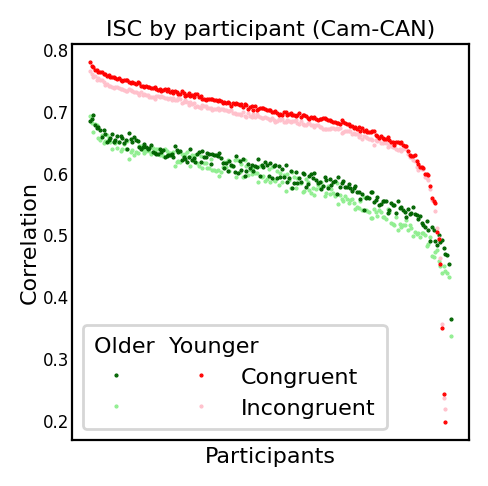

In [21]:
fig, ax = plt.subplots(1, 1, figsize=[_/3 for _ in [7, 7]], dpi=200)
handles = []
for ii, (a, b) in enumerate([[zz['old', 'old'], zz['old', 'young']], [zz['young', 'young'], zz['young', 'old']]]):
    # with sns.axes_style('darkgrid'):
        # idx = np.argsort(a)[::-1]
        idx = np.argsort((a + b))[::-1]
        a, b = np.tanh(a[idx]), np.tanh(b[idx])
        x = np.arange(len(a))
        kwargs = dict(markersize=1)
        handles += ax.plot(x, b, '.', color=colors[ii*2+1], **kwargs)
        handles += ax.plot(x, a, '.', color=colors[ii*2], **kwargs)
handles = [handles[_] for _ in [1, 0, 3, 2]]
ax.tick_params(size=0, pad=1, labelsize=6)
ax.set_ylabel('Correlation', size=8, labelpad=1)
ax.set_xticks([])
ax.set_xlabel('Participants', size=8, labelpad=2)
ax.set_title('ISC by participant (Cam-CAN)', size=8, pad=3)
ax.legend(handles=handles, labels=['', '', 'Congruent', 'Incongruent'], ncols=2, columnspacing=1, fontsize=8,
         title='Older  Younger', title_fontsize=8, alignment='left', borderpad=0.5, fancybox=True)
fig.subplots_adjust(left=0.13, top=0.92, bottom=0.07, right=0.98)
plt.savefig('figures/isc_dist_camcan.png', dpi=300)
plt.show()

In [182]:
handles

[[<matplotlib.lines.Line2D at 0x33936af30>],

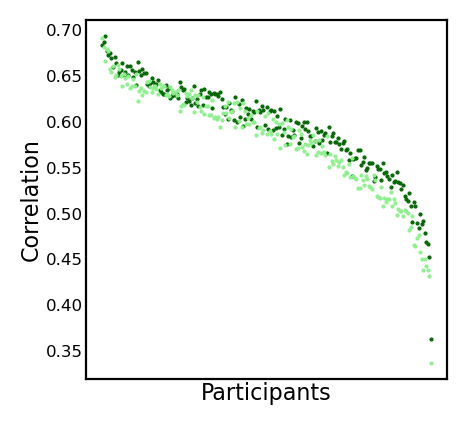

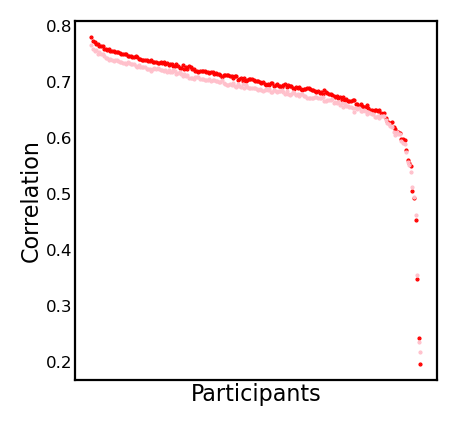

In [160]:
for ii, (a, b) in enumerate([[zz['old', 'old'], zz['old', 'young']], [zz['young', 'young'], zz['young', 'old']]]):
    # with sns.axes_style('darkgrid'):
        fig, ax = plt.subplots(1, 1, figsize=[_/3 for _ in [7, 7]], dpi=200)
        idx = np.argsort((a + b))[::-1]
        a, b = np.tanh(a[idx]), np.tanh(b[idx])
        x = np.arange(len(a))
        kwargs = dict(markersize=1)
        ax.plot(x, a, '.', color=colors[ii*2], **kwargs)
        ax.plot(x, b, '.', color=colors[ii*2+1], **kwargs)

        ax.tick_params(size=0, pad=1, labelsize=6)
        ax.set_ylabel('Correlation', size=8, labelpad=1)
        ax.set_xticks([])
        ax.set_xlabel('Participants', size=8, labelpad=1)
        plt.show()

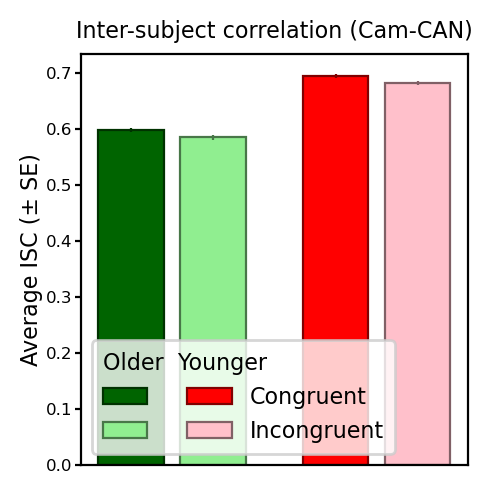

In [87]:
fig, ax = plt.subplots(1, 1, figsize=[_/3 for _ in [7, 7]], dpi=200)

bars = []
for ii, (x, z, c) in enumerate(config):
    c = colors[ii]
    ec = 0.5 * np.array(c)
    zm = z.mean()
    ze = z.std(ddof=1)/np.sqrt(len(z))
    m = np.tanh(zm)
    yerr = np.abs(np.tanh([zm-ze, zm+ze]) - m)
    b = ax.bar(x, m, color=c, ec=ec, lw=0.8)
    bars.append(b)
    ax.errorbar(x, m, yerr=yerr[:, None], color=ec, lw=0.8)
ax.set_xticks([])
ax.tick_params(size=2, pad=1, labelsize=6)
ax.set_ylabel('Average ISC (± SE)', size=8, labelpad=1)
ax.legend(handles=bars, labels=['', '', 'Congruent', 'Incongruent'], ncols=2, columnspacing=1, fontsize=8,
         title='Older  Younger', title_fontsize=8, alignment='left', borderpad=0.5, fancybox=True)
ax.set_title('Inter-subject correlation (Cam-CAN)', size=8)
fig.subplots_adjust(left=0.15, right=0.98, top=0.9, bottom=0.02)
plt.savefig('figures/isc_errorbar_camcan.png', dpi=300)
plt.show()

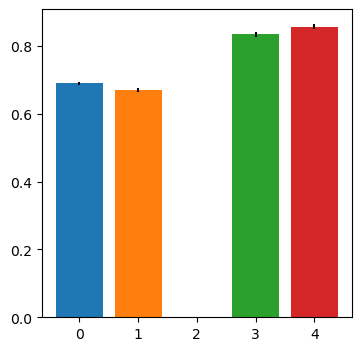

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
for ii, test_grp in enumerate(['old', 'young']):
    for jj, tpl_grp in enumerate(['old', 'young']):
        z = zz[test_grp, tpl_grp]
        x = ii * 3 + jj
        ax.bar(x, z.mean())
        ax.errorbar(x, z.mean(), yerr=z.std(ddof=1)/np.sqrt(len(z)), color='k')
plt.show()

In [13]:
ttest_rel(zz['old', 'old'], zz['old', 'young'])

TtestResult(statistic=np.float64(11.333590064196658), pvalue=np.float64(1.3821119150164137e-23), df=np.int64(212))

In [14]:
ttest_rel(zz['young', 'young'], zz['young', 'old'])

TtestResult(statistic=np.float64(30.091547363665416), pvalue=np.float64(6.627334444998706e-78), df=np.int64(209))

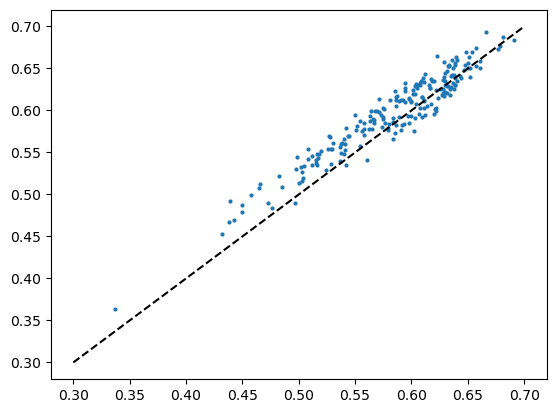

In [24]:
plt.scatter(np.tanh(zz['old', 'young']), np.tanh(zz['old', 'old']), s=4)
lim = [0.3, 0.7]
plt.plot(lim, lim, 'k--')
plt.show()

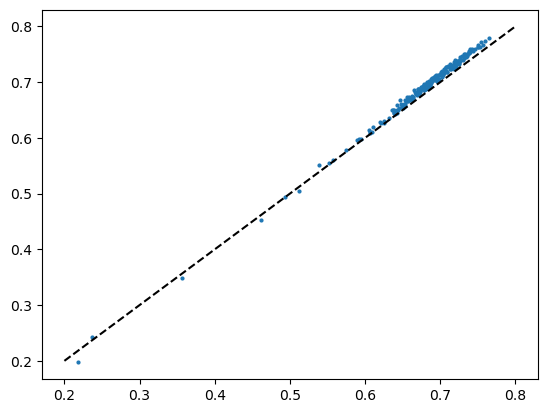

In [22]:
plt.scatter(np.tanh(zz['young', 'old']), np.tanh(zz['young', 'young']), s=4)
lim = [0.2, 0.8]
plt.plot(lim, lim, 'k--')
plt.show()